Found 320 images belonging to 2 classes.
Found 79 images belonging to 2 classes.


c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 980ms/step - accuracy: 0.7080 - loss: 0.5012

20/20 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.7161 - loss: 0.4913 - val_accuracy: 1.0000 - val_loss: 0.0680
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 787ms/step - accuracy: 1.0000 - loss: 0.0361 - val_accuracy: 1.0000 - val_loss: 0.0313
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 789ms/step - accuracy: 1.0000 - loss: 0.0144 - val_accuracy: 1.0000 - val_loss: 0.0216
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 797ms/step - accuracy: 1.0000 - loss: 0.0127 - val_accuracy: 1.0000 - val_loss: 0.0172
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 775ms/step - accuracy: 1.0000 - loss: 0.0082 - val_accuracy: 1.0000 - val_loss: 0.0168
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 806ms/step - accuracy: 1.0000 - loss: 0.0064 - val_accuracy: 1.0000 - val_loss: 0.0114
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 763ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 1.0000 - val_loss: 0.0130
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 784ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 1.0000 -

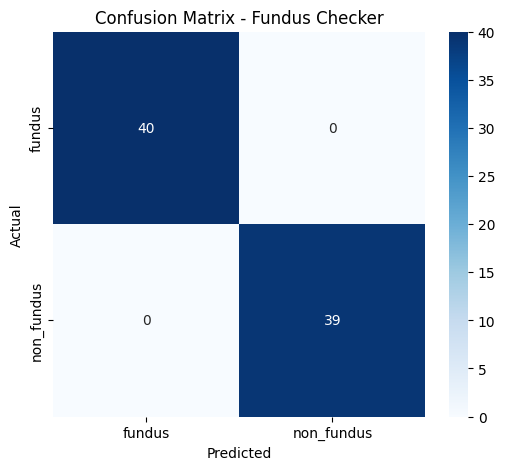


Model terbaik disimpan sebagai:
models/fundus_checker_best.h5


In [1]:
# ============================================================
# FUNDUS CHECKER TRAINING SCRIPT
# MobileNetV2 Binary Classifier (Fundus vs Non-Fundus)
# ============================================================

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


# ============================================================
# CONFIGURATION
# ============================================================

DATA_DIR = "dataset_checker"
IMG_SIZE = (224,224)
BATCH = 16
EPOCHS = 10
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# DATA GENERATOR
# ============================================================

datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='binary',
    subset='training',
    seed=SEED
)

val_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='binary',
    subset='validation',
    shuffle=False
)


# ============================================================
# MODEL ARCHITECTURE
# ============================================================

base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base.output)
out = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base.input, outputs=out)


# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# ============================================================
# CALLBACKS
# ============================================================

os.makedirs("models", exist_ok=True)

checkpoint = ModelCheckpoint(
    "models/fundus_checker_best.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


# ============================================================
# TRAIN MODEL
# ============================================================

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop]
)


# ============================================================
# EVALUATION
# ============================================================

val_gen.reset()

pred = model.predict(val_gen)
pred_labels = (pred > 0.5).astype(int).flatten()

true_labels = val_gen.classes

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        true_labels,
        pred_labels,
        target_names=list(val_gen.class_indices.keys())
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=val_gen.class_indices.keys(),
    yticklabels=val_gen.class_indices.keys()
)

plt.title("Confusion Matrix - Fundus Checker")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


print("\nModel terbaik disimpan sebagai:")
print("models/fundus_checker_best.h5")